In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [10]:
# Load Data
df = pd.read_csv("../data/processed/dataset_clean.csv", parse_dates=["timestamp"])

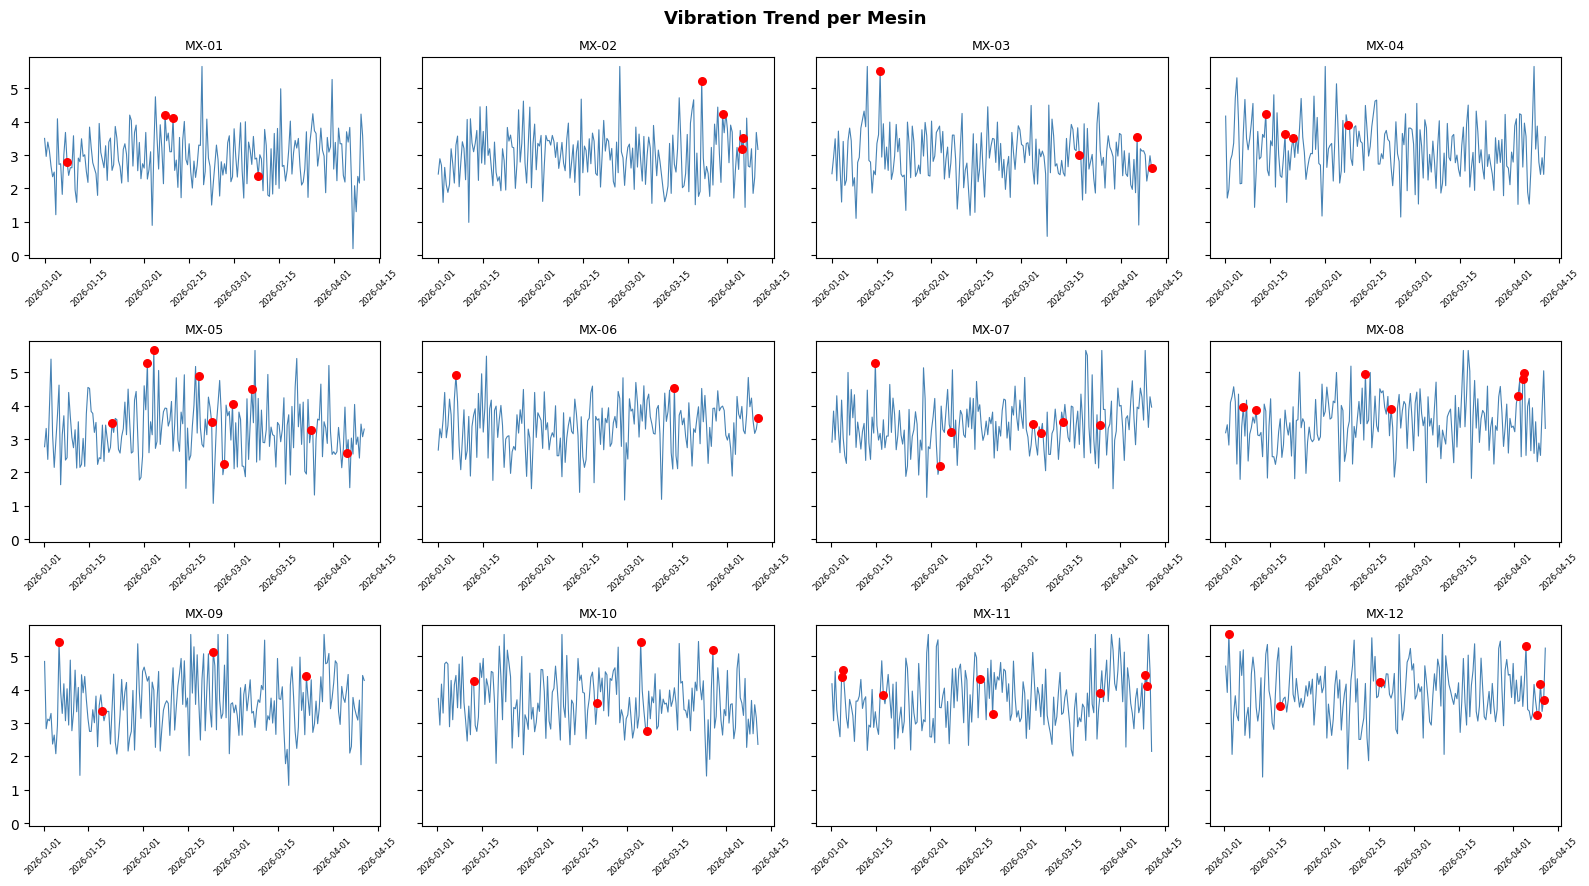

In [11]:
# Vibration trend
fig, axes = plt.subplots(3, 4, figsize=(16, 9), sharey=True)
fig.suptitle("Vibration Trend per Mesin", fontsize=13, fontweight="bold")

for ax, machine in zip(axes.flat, sorted(df["machine_id"].unique())):
    sub = df[df["machine_id"] == machine].sort_values("timestamp")
    down = sub[sub["downtime_next_24h"] == 1]

    ax.plot(sub["timestamp"], sub["vibration_mm_s"], color="steelblue", linewidth=0.8)
    ax.scatter(down["timestamp"], down["vibration_mm_s"], color="red", s=30, zorder=5)
    
    ax.set_title(machine, fontsize=9)
    ax.tick_params(axis="x", labelrotation=45, labelsize=6)

plt.tight_layout()

plt.savefig("../reports/figures/vibration_trend_per_mesin.png", dpi=300, bbox_inches="tight")

plt.show()

> **Insight:** 

Grafik di atas menampilkan tren getaran harian dari 12 mesin selama periode Januari–April 2026,
dengan titik merah menandai kapan mesin mengalami downtime.

Secara umum, getaran mesin yang sehat cenderung stabil dalam rentang tertentu. Ketika sebuah komponen
mulai aus atau longgar, mesin akan "bergetar lebih keras" dari biasanya mirip seperti mesin cuci yang
mulai bunyi aneh sebelum akhirnya rusak. Inilah yang coba ditangkap oleh fitur `vibration_mm_s`.

Dari grafik terlihat bahwa sebagian besar titik merah (downtime) muncul setelah atau bersamaan dengan
lonjakan getaran yang tidak biasa. Artinya, **getaran tinggi bisa menjadi tanda peringatan dini** bahwa
mesin perlu diperiksa — sebelum kerusakan benar-benar terjadi.

Namun perlu dicatat, tidak semua downtime didahului oleh tren naik yang jelas. Beberapa mesin mengalami
kegagalan secara tiba-tiba tanpa sinyal getaran yang menonjol sebelumnya. Ini menunjukkan bahwa getaran
saja tidak cukup untuk memprediksi kerusakan secara akurat — melainkan harus dikombinasikan dengan
informasi lain seperti jumlah alarm dan waktu sejak perawatan terakhir.

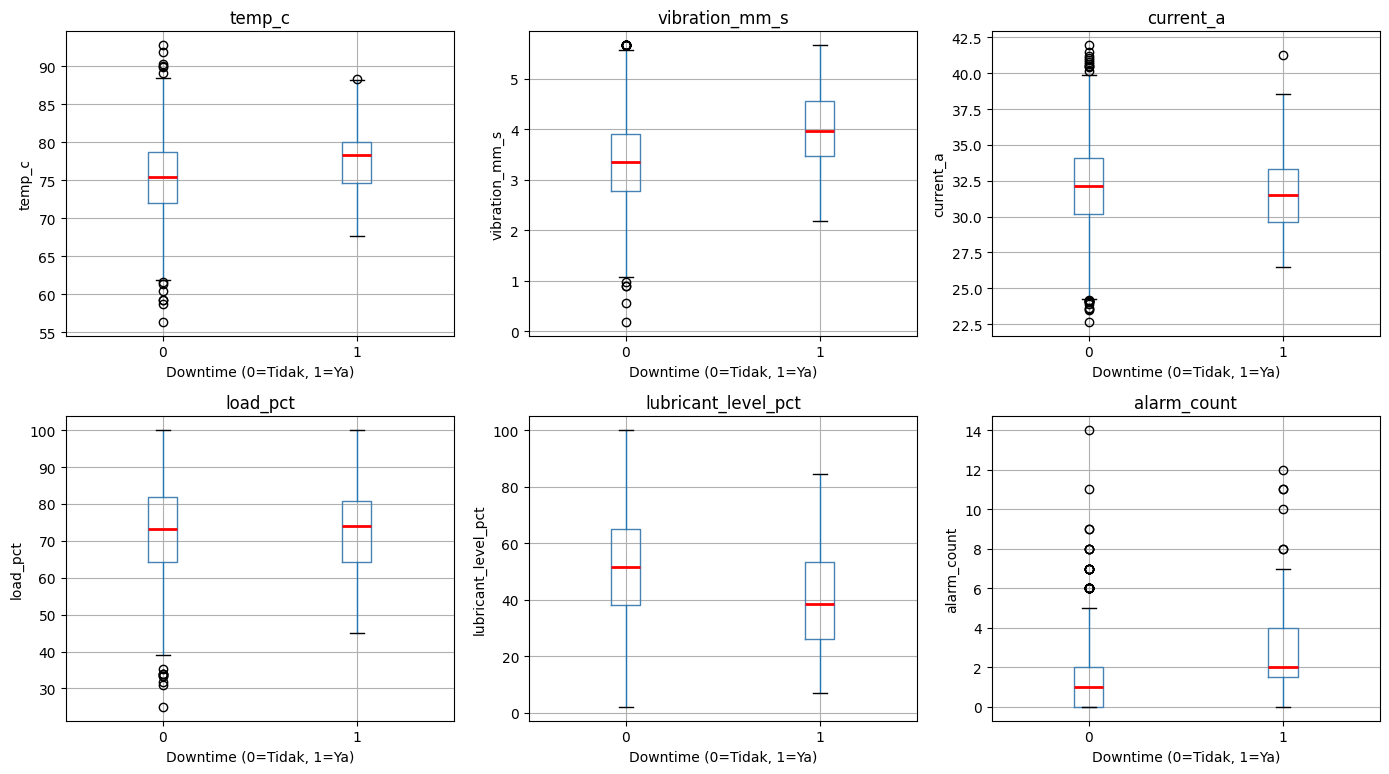

In [12]:
# Boxplot sensor vs downtime
sensor_cols = ["temp_c", "vibration_mm_s", "current_a", 
               "load_pct", "lubricant_level_pct", "alarm_count"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Boxplot Sensor vs Downtime", fontsize=13, fontweight="bold")

for ax, col in zip(axes.flat, sensor_cols):
    df.boxplot(column=col, by="downtime_next_24h", ax=ax,
               boxprops=dict(color="steelblue"),
               medianprops=dict(color="red", linewidth=2))
    
    ax.set_title(col)
    ax.set_xlabel("Downtime (0=Tidak, 1=Ya)")
    ax.set_ylabel(col)

plt.suptitle("")
plt.tight_layout()

# Simpan grafik
plt.savefig(
    "../reports/figures/boxplot_sensor_vs_downtime.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

> **Insight:** 

Boxplot di atas membandingkan distribusi setiap sensor antara kondisi normal (0) dan saat
downtime (1). Garis merah di tengah kotak menunjukkan nilai tengah (median), sementara lebar kotak
mencerminkan seberapa bervariasi pembacaan sensor tersebut.

Beberapa pola menarik terlihat dari grafik ini:

- **Suhu (`temp_c`)** — Mesin yang mengalami downtime cenderung beroperasi pada suhu yang sedikit lebih
  tinggi. Ini masuk akal: komponen yang mulai bermasalah biasanya menghasilkan panas berlebih, seperti
  rem mobil yang panas saat kampasnya habis.

- **Getaran (`vibration_mm_s`)** — Perbedaan paling mencolok terlihat di sini. Mesin normal bergetar
  di kisaran rendah, sedangkan mesin yang akan downtime bergetar jauh lebih keras. Ini menjadikan
  getaran sebagai sinyal peringatan yang paling mudah dibaca.

- **Jumlah alarm (`alarm_count`)** — Mesin yang mengalami downtime rata-rata memicu lebih banyak alarm
  sebelumnya. Artinya, sistem alarm yang sudah ada sebenarnya sudah "berteriak" — hanya saja belum
  ada sistem otomatis yang meresponsnya lebih awal.

- **Level pelumas (`lubricant_level_pct`)** — Justru sebaliknya: mesin yang downtime memiliki level
  pelumas yang *lebih rendah*. Pelumas berfungsi seperti oli pada mesin motor — kalau kurang, komponen
  saling bergesekan lebih keras dan lebih cepat aus.

- **Beban (`load_pct`) dan arus (`current_a`)** — Hampir tidak ada perbedaan berarti antara kondisi
  normal dan downtime. Ini menunjukkan bahwa kedua fitur ini kurang informatif untuk memprediksi
  kerusakan, konsisten dengan hasil feature importance sebelumnya.

Secara keseluruhan, kombinasi **getaran tinggi + alarm sering + pelumas rendah** adalah kombinasi
paling kuat sebagai tanda bahwa sebuah mesin sedang mengalami downtime.

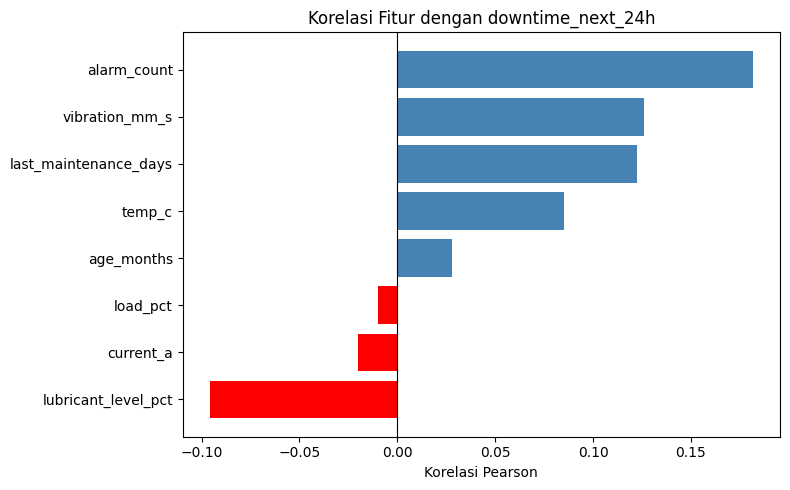

In [13]:
# Korelasi fitur 
num_cols = ["temp_c", "vibration_mm_s", "current_a", "load_pct",
            "lubricant_level_pct", "alarm_count", "age_months", "last_maintenance_days"]

corr = df[num_cols + ["downtime_next_24h"]].corr()["downtime_next_24h"].drop("downtime_next_24h").sort_values()
colors = ["red" if v < 0 else "steelblue" for v in corr]

plt.figure(figsize=(8, 5))
plt.barh(corr.index, corr.values, color=colors)
plt.axvline(0, color="black", linewidth=0.8)
plt.title("Korelasi Fitur dengan downtime_next_24h")
plt.xlabel("Korelasi Pearson")
plt.tight_layout()

plt.savefig("../reports/figures/korelasi_fitur_downtime.png", dpi=300, bbox_inches="tight")

plt.show()

> **Insight:** 

Grafik ini menunjukkan seberapa erat hubungan antara setiap fitur sensor dengan kemungkinan
terjadinya downtime dalam 24 jam ke depan. Nilai positif (biru) berarti semakin tinggi nilai sensor,
semakin besar peluang downtime — dan sebaliknya untuk nilai negatif (merah).

Tiga fitur teratas menunjukkan hubungan positif yang paling kuat:

- **Jumlah alarm (`alarm_count`)** adalah indikator paling prediktif. Semakin sering mesin memicu
  alarm, semakin tinggi risiko ia akan berhenti dalam sehari ke depan. Ini seperti tubuh manusia yang
  makin sering mengeluh sakit sebelum akhirnya benar-benar jatuh sakit.

- **Getaran (`vibration_mm_s`) dan waktu sejak perawatan terakhir (`last_maintenance_days`)** keduanya
  memiliki korelasi yang hampir sama kuatnya. Mesin yang lama tidak dirawat dan bergetar keras
  adalah kombinasi yang paling berisiko.

- **Suhu (`temp_c`)** dan **usia mesin (`age_months`)** berkontribusi lebih kecil, namun tetap
  searah — mesin yang lebih panas dan lebih tua sedikit lebih rentan.

Di sisi lain, **level pelumas (`lubricant_level_pct`)** memiliki korelasi negatif terkuat — artinya
pelumas yang *semakin rendah* justru meningkatkan risiko downtime. Ini mengonfirmasi temuan dari
boxplot sebelumnya.

**Beban mesin (`load_pct`) dan arus (`current_a`)** hampir tidak memiliki hubungan dengan downtime,
menandakan kedua sensor ini kurang berguna sebagai sinyal peringatan dini dalam dataset ini.

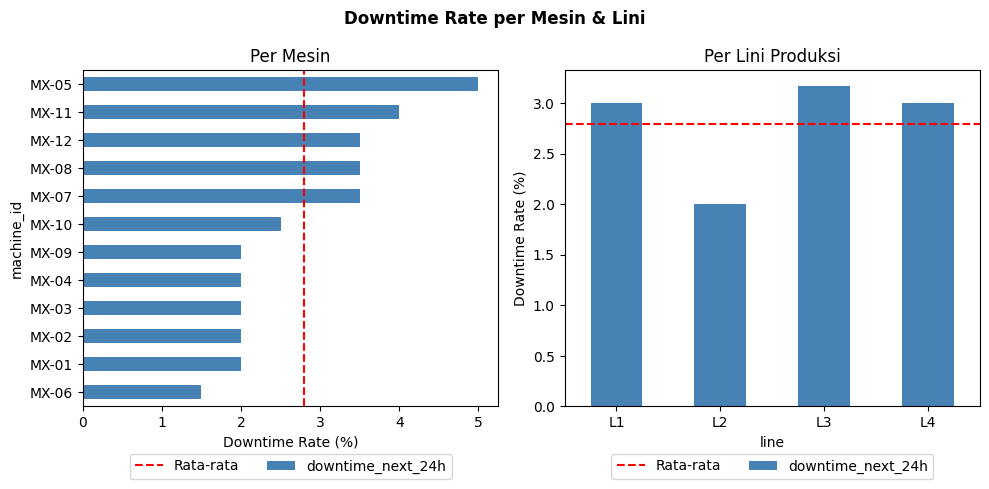

In [14]:
# Downtime rate per mesin & lini 
dt_mesin = df.groupby("machine_id")["downtime_next_24h"].mean() * 100
dt_lini  = df.groupby("line")["downtime_next_24h"].mean() * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
fig.suptitle("Downtime Rate per Mesin & Lini", fontweight="bold")

dt_mesin.sort_values().plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Per Mesin")
axes[0].set_xlabel("Downtime Rate (%)")
axes[0].axvline(dt_mesin.mean(), color="red", linestyle="--", label="Rata-rata")
axes[0].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)

dt_lini.plot(kind="bar", ax=axes[1], color="steelblue")
axes[1].set_title("Per Lini Produksi")
axes[1].set_ylabel("Downtime Rate (%)")
axes[1].axhline(dt_lini.mean(), color="red", linestyle="--", label="Rata-rata")
axes[1].tick_params(axis="x", rotation=0)
axes[1].legend(loc="upper center", bbox_to_anchor=(0.5, -0.12), ncol=2)

plt.tight_layout()

plt.savefig("../reports/figures/downtime_rate_per_mesin_dan_lini.png", dpi=300, bbox_inches="tight")

plt.show()

> **Insight:** 

Grafik ini menunjukkan seberapa sering masing-masing mesin dan lini produksi mengalami
downtime, dinyatakan dalam persentase dari total waktu operasinya.

**Per Mesin:**
MX-05 menjadi mesin paling bermasalah dengan downtime rate hampir 5% — hampir dua kali lipat
rata-rata keseluruhan (garis merah putus-putus di ~2.8%). Artinya, dari setiap 100 jam operasi,
mesin ini berhenti sekitar 5 jam. MX-11, MX-12, MX-08, dan MX-07 juga berada di atas rata-rata
dan perlu mendapat perhatian lebih. Sebaliknya, MX-06 adalah mesin paling andal dengan downtime
rate terendah di bawah 1.5%.

Pola ini penting karena tidak semua mesin sama rentannya — sumber daya perawatan sebaiknya
diprioritaskan ke mesin-mesin yang konsisten berada di atas garis rata-rata, bukan didistribusikan
merata ke semua mesin.

**Per Lini Produksi:**
Lini L3 memiliki downtime rate tertinggi (~3.2%), diikuti L1 dan L4 yang hampir setara (~3%).
Lini L2 adalah yang paling stabil dengan downtime rate hanya ~2%, jauh di bawah rata-rata.

Jika dihubungkan dengan data per mesin, tingginya downtime di L3 kemungkinan besar disumbang
oleh mesin-mesin bermasalah yang berada di lini tersebut — dan ini bisa menjadi titik awal
investigasi lebih lanjut oleh tim maintenance.

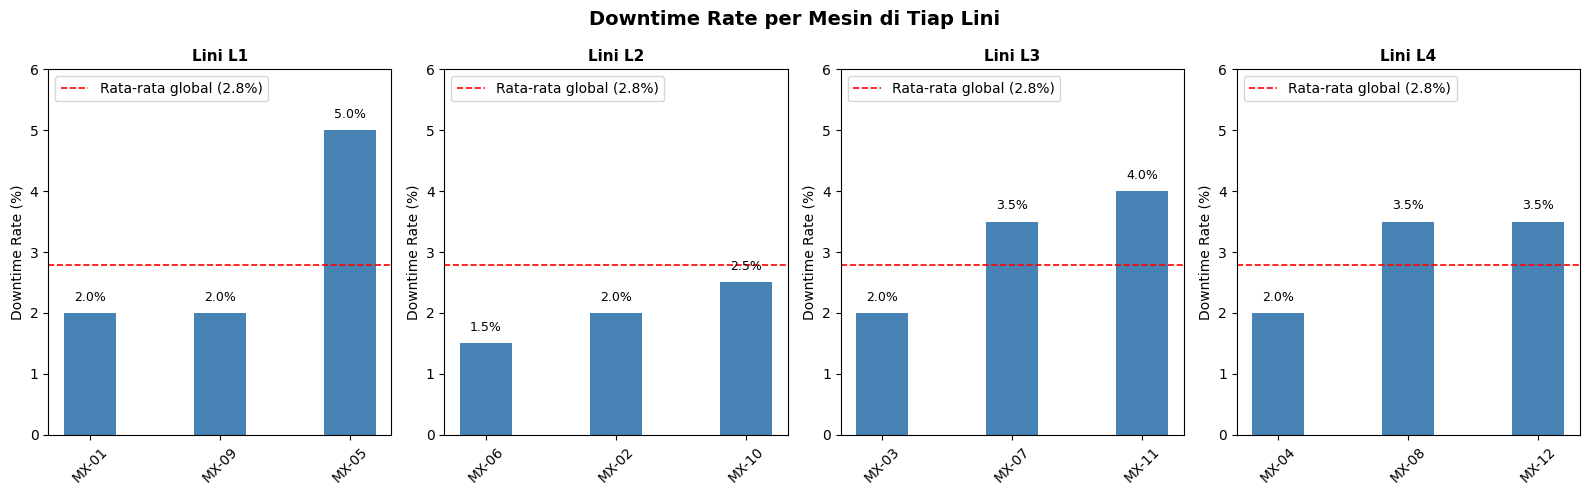

In [15]:
# Downtime rate per mesin, dikelompokkan per lini
dt_mesin_lini = df.groupby(["line", "machine_id"])["downtime_next_24h"].mean() * 100
lini_list = dt_mesin_lini.index.get_level_values("line").unique()
n_lini = len(lini_list)

fig, axes = plt.subplots(1, n_lini, figsize=(n_lini * 4, 5))
fig.suptitle("Downtime Rate per Mesin di Tiap Lini", fontweight="bold", fontsize=14)

for ax, lini in zip(axes, lini_list):
    group = dt_mesin_lini[lini].sort_values()

    bars = ax.bar(group.index, group.values, color="steelblue", width=0.4)

    ax.set_title(f"Lini {lini}", fontweight="bold", fontsize=11)
    ax.set_ylabel("Downtime Rate (%)")
    ax.axhline(
        dt_mesin_lini.mean(),
        color="red",
        linestyle="--",
        linewidth=1.2,
        label=f"Rata-rata global ({dt_mesin_lini.mean():.1f}%)"
    )
    ax.set_ylim(0, dt_mesin_lini.max() + 1)

    for bar, val in zip(bars, group.values):
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + 0.2,
            f"{val:.1f}%",
            ha="center",
            fontsize=9
        )

    ax.legend(loc="upper left")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()

plt.savefig("../reports/figures/downtime_rate_per_mesin_tiap_lini.png",
            dpi=300,
            bbox_inches="tight")

plt.show()

> **Insight:** 

Setiap lini produksi memiliki satu atau dua mesin yang mendominasi downtime di atas
rata-rata global (2.8%): **MX-05** di L1 (5.0%), **MX-11 & MX-07** di L3 (4.0% dan 3.5%),
serta **MX-08 & MX-12** di L4 (keduanya 3.5%). Lini L2 adalah yang paling stabil — semua
mesinnya berada di bawah rata-rata global.

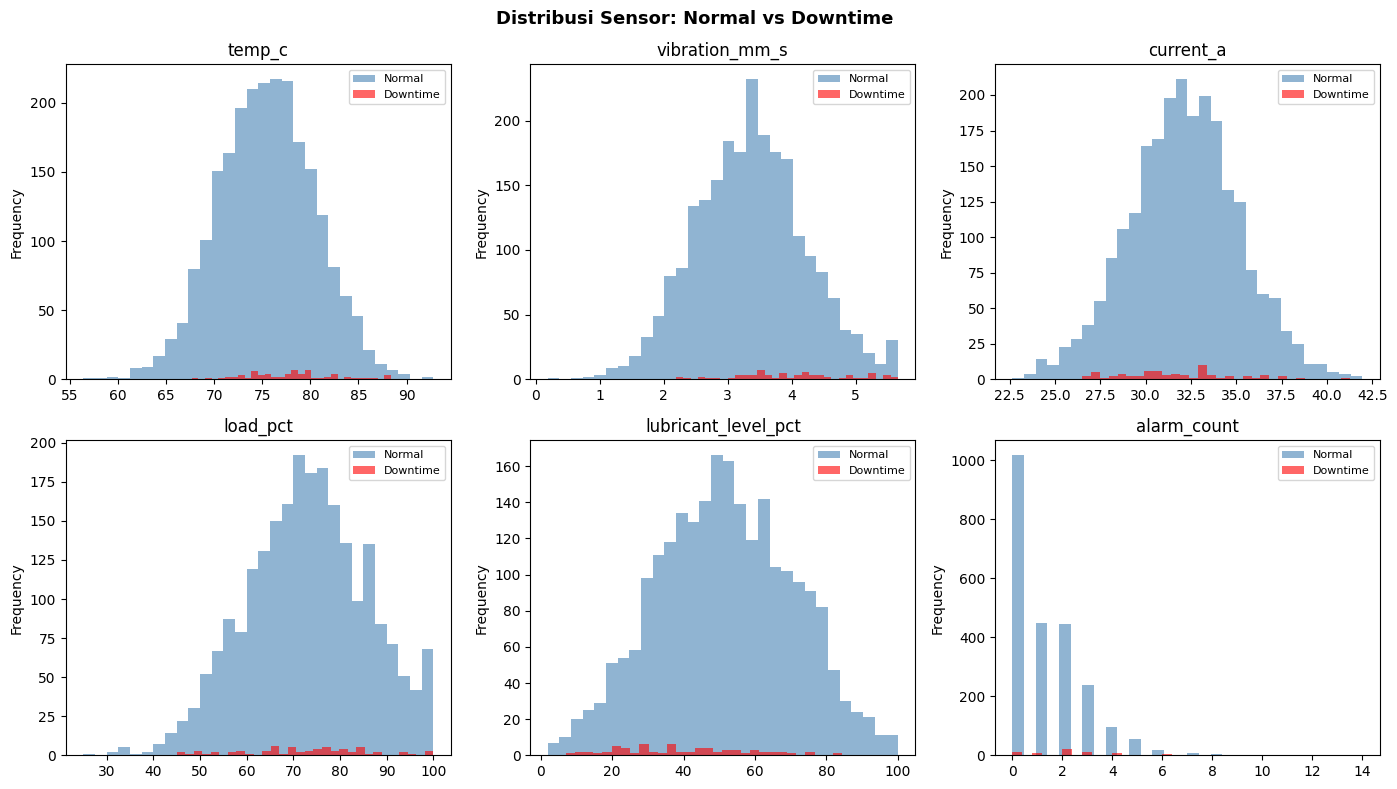

In [16]:
# Distribusi sensor
sensor_cols = ["temp_c", "vibration_mm_s", "current_a", "load_pct",
               "lubricant_level_pct", "alarm_count"]

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
fig.suptitle("Distribusi Sensor: Normal vs Downtime", fontsize=13, fontweight="bold")

for ax, col in zip(axes.flat, sensor_cols):
    df[df["downtime_next_24h"] == 0][col].plot.hist(
        ax=ax, bins=30, alpha=0.6,
        color="steelblue", label="Normal"
    )
    df[df["downtime_next_24h"] == 1][col].plot.hist(
        ax=ax, bins=30, alpha=0.6,
        color="red", label="Downtime"
    )
    ax.set_title(col)
    ax.legend(fontsize=8)

plt.tight_layout()

plt.savefig("../reports/figures/distribusi_sensor_normal_vs_downtime.png",
            dpi=300,
            bbox_inches="tight")

plt.show()